NOTE: The result interpretations should be revisited in light of the p-values adjusted for multiple comparisons.

In [ ]:
# install.packages(c("lme4", "lmerTest", "purrr", "broom.mixed", "dplyr", "tidyr", "ggplot2", "patchwork"))
library(readr)
library(lme4)
library(lmerTest)
library(purrr)
library(broom.mixed)
library(dplyr)
library(tidyr)
library(ggplot2)
library(patchwork)
library(effects)
theme_set(theme_classic())

In [ ]:
pc_data <- read_csv("../data/processed/pc_data.csv")

Rows: 732 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): participant, original, edited, explanation, explanation_embedding
dbl (10): generation, chain, edit_idx, sentence_idx, explanation_word_count,...
lgl  (1): is_cross_ref

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
summary(pc_data)

   generation        chain         participant     edit_idx     
 Min.   :1.000   Min.   : 1.0   Length   :732   Min.   : 1.000  
 1st Qu.:2.000   1st Qu.: 5.0   N.unique :102   1st Qu.: 2.000  
 Median :3.000   Median :10.0   N.blank  :  0   Median : 4.000  
 Mean   :2.949   Mean   :10.6   Min.nchar: 17   Mean   : 4.799  
 3rd Qu.:4.000   3rd Qu.:16.0   Max.nchar: 17   3rd Qu.: 7.000  
 Max.   :5.000   Max.   :21.0                   Max.   :16.000  
  sentence_idx         original         edited       explanation 
 Min.   : 0.000   Length   :732   Length   :732   Length   :732  
 1st Qu.: 2.000   N.unique :721   N.unique :688   N.unique :731  
 Median : 4.000   N.blank  :  0   N.blank  :  0   N.blank  :  0  
 Mean   : 4.393   Min.nchar: 18   Min.nchar: 33   Min.nchar:  8  
 3rd Qu.: 7.000   Max.nchar:328   Max.nchar:641   Max.nchar:604  
 Max.   :15.000                   NAs      : 41                  
 explanation_word_count is_cross_ref    explanation_embedding
 Min.   :  2.00      

# Transformations

In [ ]:
# baseline center generation (generation 1 = 0)
pc_data <- pc_data %>%
    mutate(
        generation_num = as.numeric(generation),
        generation_centered = generation_num - 1
    )

# Model fitting

In [ ]:
pcs <- paste0("pc", 1:5)

models <- map(pcs, ~ lmer(
    as.formula(paste(.x, "~ generation_centered + (1 | chain/participant)")),
    data = pc_data
))
names(models) <- pcs

boundary (singular) fit: see help('isSingular')



# Assumptions

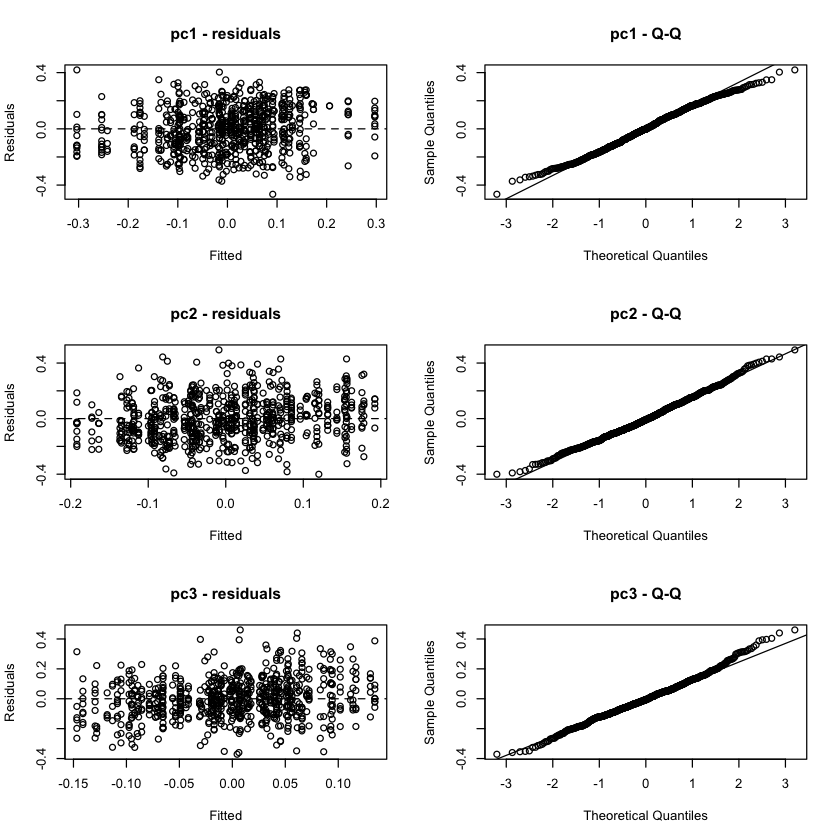

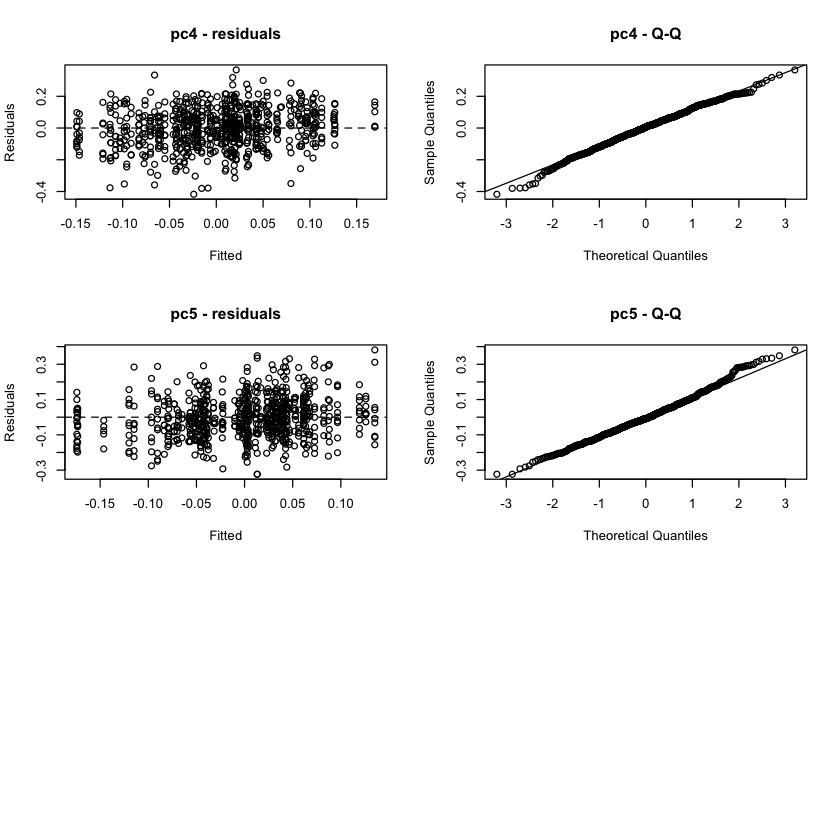

In [7]:
# chech assumptions again
par(mfrow = c(3, 2))  # 3 features x 2 plots
walk(pcs, ~ {
    m <- models[[.x]]
    # plot residuals vs fitted values
    plot(fitted(m), resid(m), main = paste(.x, "- residuals"), 
        xlab = "Fitted", ylab = "Residuals") 
    abline(h = 0, lty = 2)
    qqnorm(resid(m), main = paste(.x, "- Q-Q"))
    qqline(resid(m))
})

# Results

In [24]:
models_summary <- map(models, summary)
models_summary

is_singular <- map_lgl(models, isSingular)
print(is_singular)

$pc1
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
as.formula(paste(.x, "~ generation_centered + (1 | chain/participant)"))
   Data: edit_events_data

REML criterion at convergence: -422.1

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.87070 -0.69081 -0.01073  0.68896  2.58678 

Random effects:
 Groups            Name        Variance Std.Dev.
 participant:chain (Intercept) 0.011569 0.10756 
 chain             (Intercept) 0.002585 0.05085 
 Residual                      0.026262 0.16206 
Number of obs: 732, groups:  participant:chain, 102; chain, 21

Fixed effects:
                     Estimate Std. Error        df t value Pr(>|t|)
(Intercept)         -0.003380   0.024301 66.786571  -0.139    0.890
generation_centered  0.005789   0.008980 81.709826   0.645    0.521

Correlation of Fixed Effects:
            (Intr)
gnrtn_cntrd -0.727

$pc2
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLm

  pc1   pc2   pc3   pc4   pc5 
FALSE FALSE FALSE FALSE  TRUE 


## Collect p-values & effects

In [ ]:
p_values <- map_dbl(models_summary, ~ .x$coefficients["generation_centered", "Pr(>|t|)"])
print(p_values)

write.csv(data.frame(model = names(p_values), p_value = p_values), "p_values_explanations.csv", row.names = FALSE)

      pc1       pc2       pc3       pc4       pc5 
0.5209167 0.1821837 0.3257394 0.1455289 0.7030780 


In [10]:
# Fixed effects
fixed_effects <- map_dfr(models, tidy, effects = "fixed", .id = "outcome") |>
    filter(term == "generation_centered") |>
    mutate(
        sig = case_when(
            p.value < .001 ~ "***",
            p.value < .01  ~ "**",
            p.value < .05  ~ "*",
            TRUE           ~ "ns"
        ),
        p.value = round(p.value, 3)
    )

fixed_effects

outcome,effect,term,estimate,std.error,statistic,df,p.value,sig
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
pc1,fixed,generation_centered,0.005789367,0.008979707,0.6447168,81.70983,0.521,ns
pc2,fixed,generation_centered,-0.011695595,0.008694067,-1.3452387,83.65049,0.182,ns
pc3,fixed,generation_centered,-0.006845228,0.006919849,-0.9892163,74.96800,0.326,ns
pc4,fixed,generation_centered,0.009603888,0.006532621,1.4701431,78.32208,0.146,ns
pc5,fixed,generation_centered,-0.002391646,0.006257144,-0.3822265,103.38016,0.703,ns


In [11]:
# Random effects + variance components
random_effects <- map_dfr(models, tidy, effects = "ran_pars", .id = "outcome")
random_effects

outcome,effect,group,term,estimate
<chr>,<chr>,<chr>,<chr>,<dbl>
pc1,ran_pars,participant:chain,sd__(Intercept),0.107557893
pc1,ran_pars,chain,sd__(Intercept),0.050845230
pc1,ran_pars,Residual,sd__Observation,0.162055446
pc2,ran_pars,participant:chain,sd__(Intercept),0.103503683
pc2,ran_pars,chain,sd__(Intercept),0.005296575
pc2,ran_pars,Residual,sd__Observation,0.160757736
pc3,ran_pars,participant:chain,sd__(Intercept),0.079354000
pc3,ran_pars,chain,sd__(Intercept),0.011525495
pc3,ran_pars,Residual,sd__Observation,0.139746364


In [12]:
singular_fits <- map_lgl(models, isSingular)
print(singular_fits)

  pc1   pc2   pc3   pc4   pc5 
FALSE FALSE FALSE FALSE  TRUE 


# Plots

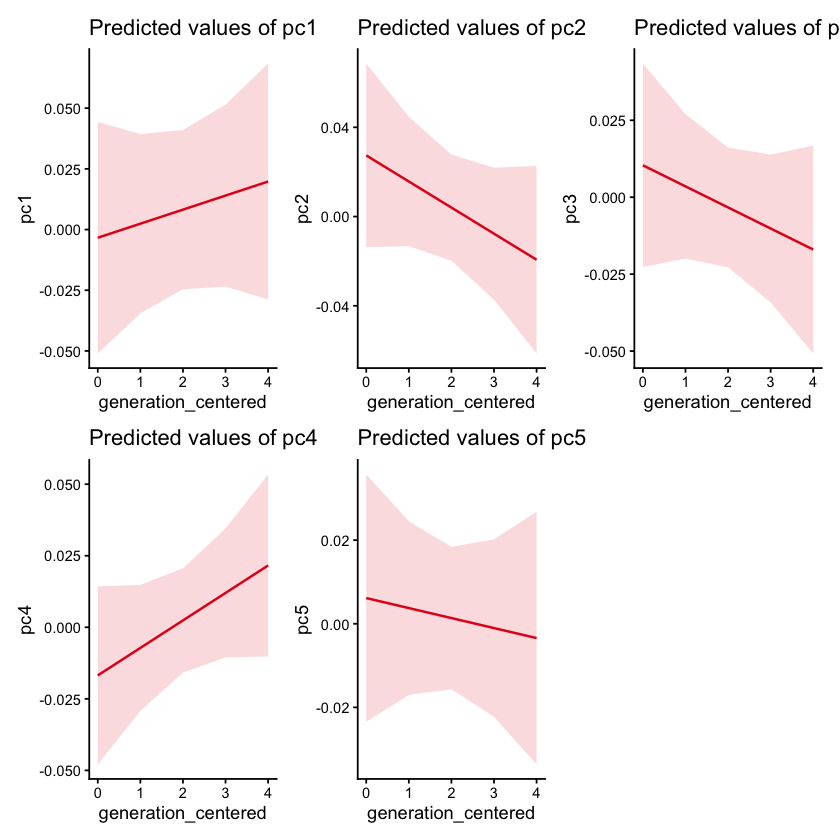

In [13]:
plots <- map(models, ~ plot_model(.x, type = "pred", terms = "generation_centered"))
wrap_plots(plots)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


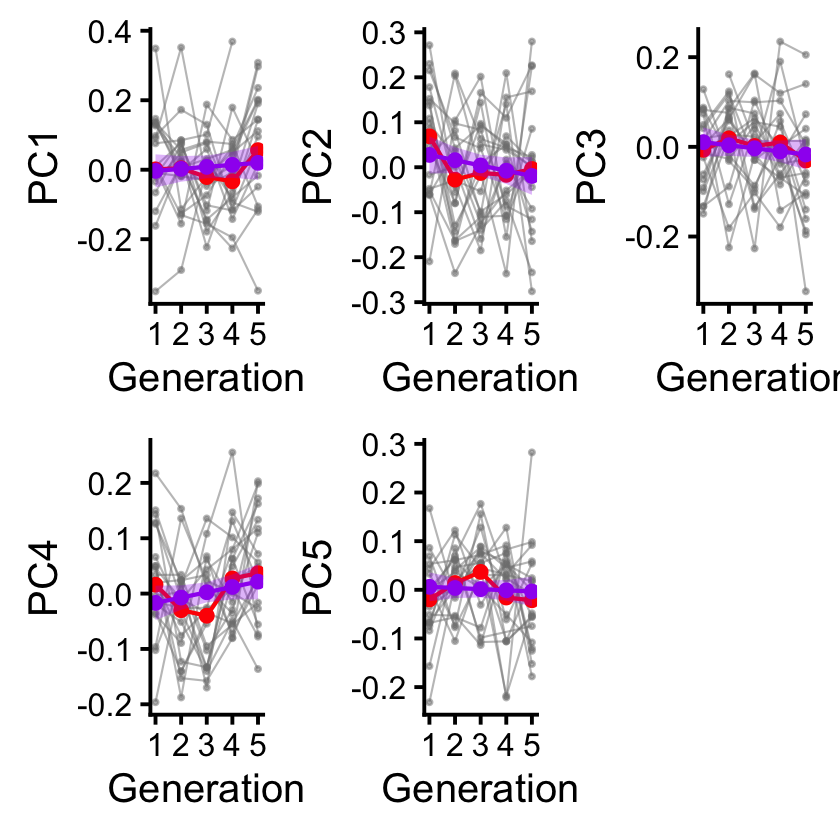

In [ ]:
effects_gen <- map(models, ~ effect(term= "generation_centered", mod= .x))

x_gen_list <- map(effects_gen, ~ as.data.frame(.x) %>%
    mutate(generation_num = generation_centered + 1))

chain_means <- pc_data %>%
    group_by(chain, generation_num) %>%
    summarise(across(all_of(pcs), mean), .groups = "drop") %>%
    pivot_longer(cols = all_of(pcs), names_to = "pc", values_to = "chain_mean") %>%
    mutate(pc = factor(pc, levels = pcs))

overall_means <- pc_data %>%
    group_by(generation_num) %>%
    summarise(across(all_of(pcs), mean), .groups = "drop") %>%
    pivot_longer(cols = all_of(pcs), names_to = "pc", values_to = "overall_mean") %>%
    mutate(pc = factor(pc, levels = pcs))

plots <- map2(x_gen_list, pcs, ~ {
    pc_chain_means <- chain_means %>% filter(pc == .y)

    ggplot() +
        # points for per-generation chain means
        geom_point(data = pc_chain_means,
                    aes(x = generation_num, y = chain_mean),
                    size = 0.8, alpha=0.5, colour = "grey50") +
        # lines linking chain means across generations (with same color as points)
        geom_line(data = pc_chain_means,
                    aes(x = generation_num, y = chain_mean, group = chain),
                    size = 0.6, alpha=0.5, colour = "grey50") +
        # points for overall means 
        geom_point(data = overall_means %>% filter(pc == .y),
                    aes(x = generation_num, y = overall_mean),
                    colour = "red", size = 3) +
        geom_line(data = overall_means %>% filter(pc == .y),
                    aes(x = generation_num, y = overall_mean),
                    colour = "red", linewidth=1.2) +
        # points for model estimates
        geom_point(data = .x, aes(x = generation_num, y = fit),
                    colour = "purple", size = 3) +
        # line for model estimates (same color as estimate points)
        geom_line(data = .x, aes(x = generation_num, y = fit),
                    colour = "purple", linewidth=1.2) +
        # ribbon for CI of estimates (same color as estimate points, with alpha for transparency)
        geom_ribbon(data = .x, aes(x = generation_num, ymin = lower, ymax = upper),
                    fill = "purple", alpha = 0.3) +
        labs(x = "Generation", y = toupper(.y)) +
        theme_classic(base_size = 24)
})

p <- wrap_plots(plots)
p
# ggsave("figs/pc_model_fits.pdf", plot = p, width = 6, height = 4)


# save plots individually
for (i in seq_along(plots)) {
    ggsave(paste0("figs/pcs_model_fits/", pcs[i], "_model_fit.pdf"), plot = plots[[i]], width = 6, height = 5)
}

# Exploratory: non-linear effects

In [ ]:
pc_data$generation_centered_sq <- pc_data$generation_centered^2


models_quad <- map(pcs, ~ lmer(
    as.formula(paste(.x, "~ generation_centered + generation_centered_sq + (1 | chain/participant)")),
    data = pc_data,
))

for (i in seq_along(models_quad)) {
    print(paste("Summary for model:", pcs[i]))
    print(summary(models_quad[[i]]))
    cat("\n\n----------------------------------\n\n")
}

singular_fits_quad <- map_lgl(models_quad, isSingular)
print(singular_fits_quad)

boundary (singular) fit: see help('isSingular')



[1] "Summary for model: pc1"
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
as.formula(paste(.x, "~ generation_centered + generation_centered_sq + (1 | chain/participant)"))
   Data: edit_events_data

REML criterion at convergence: -418.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.8386 -0.7018  0.0070  0.6895  2.5446 

Random effects:
 Groups            Name        Variance Std.Dev.
 participant:chain (Intercept) 0.010809 0.1040  
 chain             (Intercept) 0.002981 0.0546  
 Residual                      0.026239 0.1620  
Number of obs: 732, groups:  participant:chain, 102; chain, 21

Fixed effects:
                       Estimate Std. Error       df t value Pr(>|t|)  
(Intercept)             0.02959    0.02856 85.44774   1.036   0.3030  
generation_centered    -0.05844    0.03053 80.50815  -1.914   0.0592 .
generation_centered_sq  0.01613    0.00733 81.00006   2.201   0.0306 *
---
Signif. codes:  0 ‘***’ 0.001 

In [ ]:
# summarize quadratic model fixed effects
fixed_effects_quad <- map_dfr(models_quad, tidy, effects = "fixed", .id = "pc") |>
    filter(term %in% c("generation_centered", "generation_centered_sq")) |>
    mutate(
        sig = case_when(
            p.value < .001 ~ "***",
            p.value < .01  ~ "**",
            p.value < .05  ~ "*",
            TRUE           ~ "ns"
        ),
        p.value = round(p.value, 3)
    )
fixed_effects_quad

pc,effect,term,estimate,std.error,statistic,df,p.value,sig
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,fixed,generation_centered,-0.058443526,0.030532098,-1.914167,80.50815,0.059,ns
1,fixed,generation_centered_sq,0.016131895,0.007330067,2.200784,81.00006,0.031,*
2,fixed,generation_centered,-0.064253051,0.029700137,-2.163392,81.45001,0.033,*
2,fixed,generation_centered_sq,0.013161886,0.007129222,1.846188,81.88520,0.068,ns
3,fixed,generation_centered,0.024974031,0.023990333,1.041004,74.24824,0.301,ns
3,fixed,generation_centered_sq,-0.007974605,0.005759505,-1.384599,74.66793,0.170,ns
4,fixed,generation_centered,-0.049262404,0.021918487,-2.247528,78.47480,0.027,*
4,fixed,generation_centered_sq,0.014774409,0.005262092,2.807706,78.91542,0.006,**
5,fixed,generation_centered,0.043868661,0.021324640,2.057182,101.68151,0.042,*


In [ ]:
# compare linear vs quadratic models using AIC and likelihood ratio tests
model_comparison <- tibble(
    model = names(models),
    aic_linear = map_dbl(models, AIC),
    aic_quad = map_dbl(models_quad, AIC),
    delta_aic = aic_quad - aic_linear,
    better_model_aic = ifelse(aic_linear < aic_quad, "linear", "quadratic"),
    bic_linear = map_dbl(models, BIC),
    bic_quad = map_dbl(models_quad, BIC),
    delta_bic = bic_quad - bic_linear,
    better_model_bic = ifelse(bic_linear < bic_quad, "linear", "quadratic")
)

# Add likelihood ratio tests
lr_tests <- map2_dfr(models, models_quad, ~ {
    lr_test <- anova(.x, .y)
    data.frame(
        chisq = lr_test$Chisq[2],
        df_diff = lr_test$Df[2],
        p_value = lr_test$`Pr(>Chisq)`[2]
    )
}, .id = "model")

model_comparison <- bind_cols(model_comparison, lr_tests %>% select(-model))

model_comparison <- model_comparison %>%
    mutate(
        better_model_lr = ifelse(p_value < 0.05, "quadratic", "linear"),
    )

model_comparison

refitting model(s) with ML (instead of REML)

refitting model(s) with ML (instead of REML)

refitting model(s) with ML (instead of REML)

refitting model(s) with ML (instead of REML)

refitting model(s) with ML (instead of REML)



model,aic_linear,aic_quad,delta_aic,better_model_aic,bic_linear,bic_quad,delta_bic,better_model_bic,chisq,df_diff,p_value,better_model_lr
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
pc1,-412.0983,-406.8317,5.266672,linear,-389.1194,-379.2570,9.862452,linear,4.754853,1,0.029215788,quadratic
pc2,-439.7484,-433.0483,6.700105,linear,-416.7695,-405.4736,11.295885,linear,3.401914,1,0.065120812,linear
pc3,-660.5862,-652.0257,8.560510,linear,-637.6073,-624.4510,13.156290,linear,1.945794,1,0.163040829,linear
pc4,-798.9938,-796.0104,2.983402,linear,-776.0149,-768.4357,7.579183,linear,7.772678,1,0.005304236,quadratic
pc5,-855.9527,-850.2877,5.664939,linear,-832.9738,-822.7130,10.260720,linear,5.151123,1,0.023231346,quadratic


**Interpretation**:

- For pc1, pc4, pc5, there is a detectable quadratic pattern (p < 0.05), but the linear model has better predictive performance (lower AIC/BIC), meaning the quadratic curvature is real but weak. 
- For pc2, the effect of the quadratic term is marginal (p = 0.065), so the linear model is favored by AIC/BIC as well.
- For pc3, the quadratic term is not significant (p = 0.163), so the linear model is clearly favored.

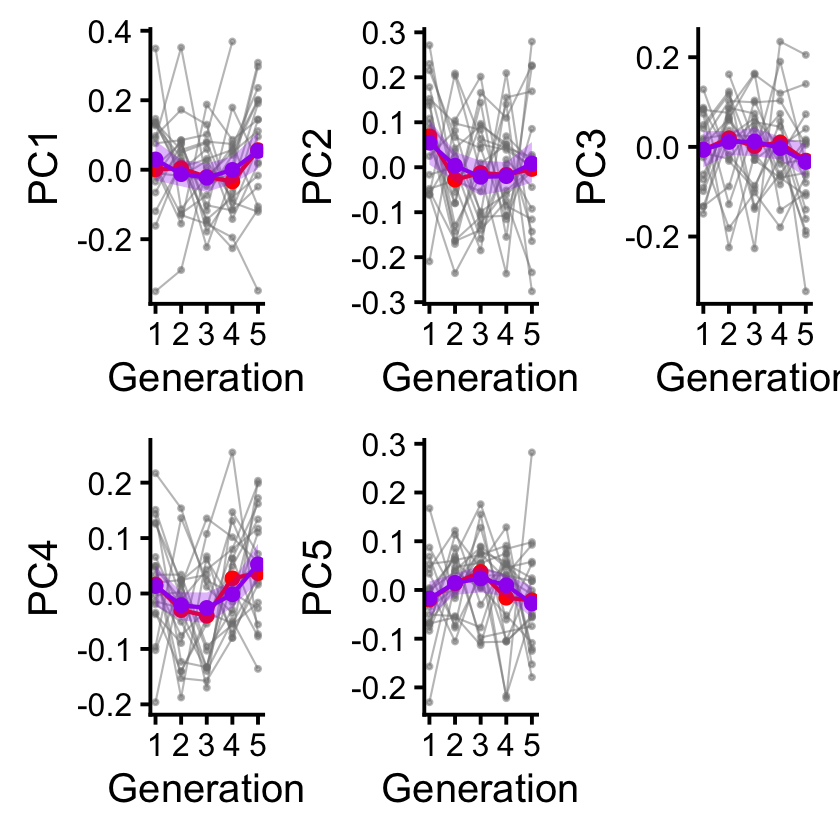

In [ ]:
# prediction grid for quadratic fits
pred_grid <- tibble(
    generation_centered = seq(min(pc_data$generation_centered),
                                max(pc_data$generation_centered),
                                length.out = 5)
    ) %>%
    mutate(
        generation_centered_sq = generation_centered^2,
        generation_num = generation_centered + 1
    )


# bootstrap confidence intervals for quadratic model predictions
boot_pred_fun <- function(mod) {
    predict(mod, newdata = pred_grid, re.form = NA, allow.new.levels = TRUE)
}

boot_list <- map(models_quad, ~ bootMer(
    .x,
    FUN = boot_pred_fun,
    nsim = 200,
    type = "parametric",
    seed = 123
))

x_gen_list <- map2(boot_list, models_quad, ~ {
    fit0 <- predict(.y, newdata = pred_grid, re.form = NA, allow.new.levels = TRUE)
    sims <- .x$t
    tibble(
        generation_centered = pred_grid$generation_centered,
        generation_centered_sq = pred_grid$generation_centered_sq,
        generation_num = pred_grid$generation_num,
        fit = fit0,
        lower = apply(sims, 2, quantile, 0.025, na.rm = TRUE),
        upper = apply(sims, 2, quantile, 0.975, na.rm = TRUE)
    )
})

# chain means for raw data
chain_means <- pc_data %>%
    group_by(chain, generation_num) %>%
    summarise(across(all_of(pcs), mean), .groups = "drop") %>%
    pivot_longer(cols = all_of(pcs), names_to = "pc", values_to = "chain_mean") %>%
    mutate(pc = factor(pc, levels = pcs))

# overall means for raw data
overall_means <- pc_data %>%
    group_by(generation_num) %>%
    summarise(across(all_of(pcs), mean), .groups = "drop") %>%
    pivot_longer(cols = all_of(pcs), names_to = "pc", values_to = "overall_mean") %>%
    mutate(pc = factor(pc, levels = pcs))   

plots <- map2(x_gen_list, pcs, ~ {
    pc_chain_means <- chain_means %>% filter(pc == .y)

    ggplot() +
        geom_point(data = pc_chain_means,
            aes(x = generation_num, y = chain_mean),
            size = 0.8, alpha = 0.5, colour = "grey50"
        ) +
        geom_line(data = pc_chain_means,
            aes(x = generation_num, y = chain_mean, group = chain),
            size = 0.6, alpha = 0.5, colour = "grey50"
        ) +
        geom_point(data = overall_means %>% filter(pc == .y),
            aes(x = generation_num, y = overall_mean),
            colour = "red", size = 3
        ) +
        geom_line(data = overall_means %>% filter(pc == .y),
            aes(x = generation_num, y = overall_mean),
            colour = "red", linewidth = 1.2
        ) +
        geom_point(data = .x,
            aes(x = generation_num, y = fit),
            colour = "purple", size=3
        ) +
        geom_line(data = .x,
            aes(x = generation_num, y = fit),
            colour = "purple", linewidth = 1.2
        ) +
        geom_ribbon(data = .x,
            aes(x = generation_num, ymin = lower, ymax = upper),
            alpha = 0.3, fill = "purple"
        ) +
        labs(x = "Generation", y = toupper(.y)) +
        theme_classic(base_size = 24)
})

p <- wrap_plots(plots)
p

ggsave("figs/pcs_model_fits/quadratic/pc_model_fits_quadratic.pdf", plot = p, width = 6, height = 4)

for (i in seq_along(plots)) {
    ggsave(paste0("figs/pcs_model_fits/quadratic/", pcs[i], "_model_fit_quadratic.pdf"), plot = plots[[i]], width = 6, height = 5)
}

Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image


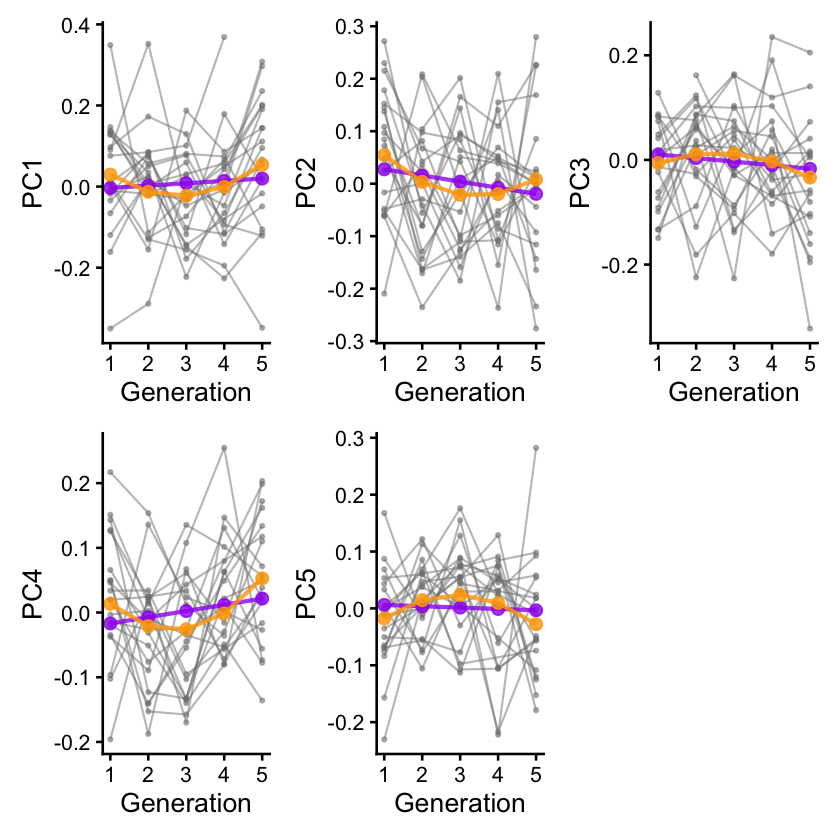

In [ ]:
# overlay the linear and quadratic fits for each PC
x_gen_list_linear <- map(models, ~ {
    grid <- pred_grid %>% select(generation_centered, generation_num)
    fit <- predict(.x, newdata = grid, re.form = NA, allow.new.levels = TRUE)
    grid$fit <- fit
    grid
})  

plots_overlay <- pmap(list(pcs, x_gen_list, x_gen_list_linear), ~ {
    pc_chain_means <- chain_means %>% filter(pc == ..1)

    ggplot() +
        geom_point(
            data = pc_chain_means,
            aes(x = generation_num, y = chain_mean),
            size = 0.8, alpha = 0.5, colour = "grey50"
        ) +
        geom_line(
            data = pc_chain_means,
            aes(x = generation_num, y = chain_mean, group = chain),
            size = 0.6, alpha = 0.5, colour = "grey50"
        ) +
        geom_point(
            data = ..3,
            aes(x = generation_num, y = fit),
            colour = "purple", size=3, alpha=0.8
        ) +
        geom_line(
            data = ..3,
            aes(x = generation_num, y = fit),
            colour = "purple", linewidth=1.2, alpha=0.8
        ) +
        geom_point(
            data = ..2,
            aes(x = generation_num, y = fit),
            colour = "orange", size=3, alpha=0.8
        ) +
        geom_line(
            data = ..2,
            aes(x = generation_num, y = fit),
            colour = "orange", linewidth = 1.2, alpha = 0.8
        ) +
        # geom_ribbon(
            # data = ..2,
            # aes(x = generation_num, ymin = lower, ymax = upper),
            # alpha = 0.3, fill = "purple"
        # ) +
        labs(x = "Generation", y = toupper(..1)) +
        theme_classic(base_size = 16)
})

p_overlay <- wrap_plots(plots_overlay)
p_overlay


ggsave("figs/pcs_model_fits/quadratic/pc_model_fits_overlayed.pdf", plot = p_overlay, width = 6, height = 4)

for (i in seq_along(plots)) {
    ggsave(paste0("figs/pcs_model_fits/quadratic/", pcs[i], "_model_fit_overlayed.pdf"), plot = plots[[i]])
}

# Exploratory: covariates

In [ ]:
# import responses data to get demographics
responses_data <- read_csv("../data/processed/responses_combined_processed.csv")

# create a participant-level demographics table (one row per participant)
# ResponseId in responses_data corresponds to participant in pc_data
responses_unique <- responses_data %>%
    distinct(ResponseId, .keep_all = TRUE) %>%
    rename(participant = ResponseId)

# combine with edit events data to get demographics for each edit event
demog_data <- pc_data %>%
    left_join(responses_unique, by = "participant")

Rows: 105 Columns: 43
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (27): Status, ResponseId, DistributionChannel, UserLanguage, consent, c...
dbl  (10): Progress, Duration (in seconds), Q_RecaptchaScore, age, g, c, res...
lgl   (3): Finished, Q_RecaptchaError, made_edits
dttm  (3): StartDate, EndDate, RecordedDate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [27]:
# relevel factors for more meaningful interpretation
demog_data <- demog_data %>%
    mutate(
        LLM_use = factor(
            LLM_use,
            levels = c(
                "I have never used an AI chatbot / LLM",
                "I have not used any AI chatbot / LLM in the past 30 days",
                "Once in the past month",
                "2-3 times in the past month",
                "About once a week",
                "Several times per week",
                "Every day or almost every day"
            ),
            ordered = TRUE
        ),

        LLM_impact = relevel(
            factor(LLM_impact_abbrev),
            ref = "No impact"
        ),

        writing_style_pre = factor(
            writing_style_pre,
            levels = c("Not at all", "Somewhat", "A lot"),
            ordered = TRUE
        )
    )


levels(demog_data$LLM_use)
levels(demog_data$LLM_impact)
levels(demog_data$writing_style_pre)

[1] "I have never used an AI chatbot / LLM"                   
[2] "I have not used any AI chatbot / LLM in the past 30 days"
[3] "Once in the past month"                                  
[4] "2-3 times in the past month"                             
[5] "About once a week"                                       
[6] "Several times per week"                                  
[7] "Every day or almost every day"

[1] "No impact"                   "More negative than positive"
[3] "More positive than negative" "No opinion"                 
[5] "Very beneficial"             "Very detrimental"

[1] "Not at all" "Somewhat"   "A lot"

In [17]:
models_demog <- map(pcs, ~ lmer(
    as.formula(paste(.x, "~ generation_centered + age + LLM_use + LLM_impact + writing_style_pre + (1 | chain/participant)")),
    data = demog_data
))

for (i in seq_along(models_demog)) {
    print(paste("Summary for model:", pcs[i]))
    print(summary(models_demog[[i]]))
}

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



[1] "Summary for model: pc1"
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
as.formula(paste(.x, "~ generation_centered + age + LLM_use + LLM_impact + writing_style_pre + (1 | chain/participant)"))
   Data: demog_data

REML criterion at convergence: -369.5

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.93424 -0.68462 -0.00498  0.68975  2.60828 

Random effects:
 Groups            Name        Variance  Std.Dev.
 participant:chain (Intercept) 0.0138807 0.11782 
 chain             (Intercept) 0.0001841 0.01357 
 Residual                      0.0262211 0.16193 
Number of obs: 732, groups:  participant:chain, 102; chain, 21

Fixed effects:
                                        Estimate Std. Error         df t value
(Intercept)                           -7.367e-02  1.064e-01  1.048e+02  -0.692
generation_centered                    1.070e-02  1.041e-02  7.169e+01   1.028
age                                    1.875e-04 


Correlation matrix not shown by default, as p = 16 > 12.
Use print(summary(models_demog[[i]]), correlation=TRUE)  or
    vcov(summary(models_demog[[i]]))        if you need it




[1] "Summary for model: pc2"
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
as.formula(paste(.x, "~ generation_centered + age + LLM_use + LLM_impact + writing_style_pre + (1 | chain/participant)"))
   Data: demog_data

REML criterion at convergence: -399

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.4944 -0.6505 -0.0633  0.6413  3.0934 

Random effects:
 Groups            Name        Variance Std.Dev.
 participant:chain (Intercept) 0.01029  0.1014  
 chain             (Intercept) 0.00000  0.0000  
 Residual                      0.02584  0.1607  
Number of obs: 732, groups:  participant:chain, 102; chain, 21

Fixed effects:
                                        Estimate Std. Error         df t value
(Intercept)                           -9.141e-03  9.544e-02  1.027e+02  -0.096
generation_centered                   -1.708e-02  9.287e-03  8.524e+01  -1.839
age                                   -6.951e-04  1.033e-03  8.34


Correlation matrix not shown by default, as p = 16 > 12.
Use print(summary(models_demog[[i]]), correlation=TRUE)  or
    vcov(summary(models_demog[[i]]))        if you need it




...

[1] "Summary for model: pc4"
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
as.formula(paste(.x, "~ generation_centered + age + LLM_use + LLM_impact + writing_style_pre + (1 | chain/participant)"))
   Data: demog_data

REML criterion at convergence: -740.9

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.3512 -0.6059  0.0342  0.6339  2.8042 

Random effects:
 Groups            Name        Variance  Std.Dev.
 participant:chain (Intercept) 0.0065056 0.08066 
 chain             (Intercept) 0.0001108 0.01052 
 Residual                      0.0159751 0.12639 
Number of obs: 732, groups:  participant:chain, 102; chain, 21

Fixed effects:
                                        Estimate Std. Error         df t value
(Intercept)                           -4.663e-02  7.600e-02  9.834e+01  -0.614
generation_centered                    9.713e-03  7.369e-03  6.821e+01   1.318
age                                   -1.262e-04  8.249e-04


Correlation matrix not shown by default, as p = 16 > 12.
Use print(summary(models_demog[[i]]), correlation=TRUE)  or
    vcov(summary(models_demog[[i]]))        if you need it




[1] "Summary for model: pc5"
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
as.formula(paste(.x, "~ generation_centered + age + LLM_use + LLM_impact + writing_style_pre + (1 | chain/participant)"))
   Data: demog_data

REML criterion at convergence: -796.9

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.67937 -0.61926 -0.06759  0.60716  3.10797 

Random effects:
 Groups            Name        Variance Std.Dev.
 participant:chain (Intercept) 0.00581  0.07622 
 chain             (Intercept) 0.00000  0.00000 
 Residual                      0.01484  0.12183 
Number of obs: 732, groups:  participant:chain, 102; chain, 21

Fixed effects:
                                        Estimate Std. Error         df t value
(Intercept)                            5.091e-02  7.193e-02  1.049e+02   0.708
generation_centered                   -4.696e-03  6.995e-03  8.707e+01  -0.671
age                                    6.668e-04  7.7


Correlation matrix not shown by default, as p = 16 > 12.
Use print(summary(models_demog[[i]]), correlation=TRUE)  or
    vcov(summary(models_demog[[i]]))        if you need it




optimizer (nloptwrap) convergence code: 0 (OK)
boundary (singular) fit: see help('isSingular')

